# RQ7 — Error Analysis on Hard-to-Classify Movies

**Research question:** What characterizes the movies the model misclassifies, and what does this reveal about the limits of pre-release predictability?

This notebook computes the confusion matrix and profiles the average feature values of true positives, true negatives, false positives, and false negatives.

## 1. Setup and imports

In [1]:
# Imports
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available, skipping XGBoost model")

# Plot styling
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

COLORS = {
    "primary":   "#185FA5",
    "accent":    "#D85A30",
    "secondary": "#1D9E75",
    "gray":      "#888780",
    "amber":     "#BA7517",
    "purple":    "#7F77DD",
    "pink":      "#D4537E",
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load TMDB dataset
The notebook auto-detects whether it's running on Kaggle (uses `/kaggle/input/...`) or locally.

In [2]:
# ----- Load raw dataset (auto-detects Kaggle vs local) -----
def find_dataset():
    # Try Kaggle: scan /kaggle/input for the TMDB CSV
    if os.path.exists("/kaggle/input"):
        for csv in glob.glob("/kaggle/input/**/*.csv", recursive=True):
            if "tmdb" in csv.lower() or "movies" in csv.lower():
                return csv
    # Fallback: local file
    for candidate in ["TMDB_all_movies.csv", "../TMDB_all_movies.csv"]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError("Could not find TMDB CSV. On Kaggle, attach 'TMDB Movies Daily Updates' dataset. Locally, place TMDB_all_movies.csv in this folder.")

DATA_PATH = find_dataset()
print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")


Loading dataset from: TMDB_all_movies.csv


Raw dataset shape: (1188481, 28)


## 3. Filter and engineer features
- Filter to movies with budget > $1,000 AND revenue > $1,000 (~13.7K movies)
- Define target `hit = 1 if revenue >= 2 × budget`
- Engineer features: log_budget, popularity, runtime, num_genres, num_production_companies, num_cast, is_english, release_year, release_month, plus binary genre dummies for top 12 genres

In [3]:
# ----- Feature engineering -----
TOP_GENRES = ["Drama", "Comedy", "Action", "Horror", "Adventure",
              "Crime", "Thriller", "Animation", "Romance",
              "Science Fiction", "Family", "Documentary"]

def build_modeling_df(df):
    m = df[(df["budget"] > 1000) & (df["revenue"] > 1000)].copy()
    m["hit"] = (m["revenue"] >= 2 * m["budget"]).astype(int)
    m["release_date"] = pd.to_datetime(m["release_date"], errors="coerce")
    m["release_year"] = m["release_date"].dt.year
    m["release_month"] = m["release_date"].dt.month
    m["log_budget"] = np.log1p(m["budget"])
    m["log_popularity"] = np.log1p(m["popularity"].fillna(0))
    m["num_genres"] = m["genres"].fillna("").apply(lambda s: len([g for g in s.split(",") if g.strip()]))
    m["num_production_companies"] = m["production_companies"].fillna("").apply(
        lambda s: len([c for c in s.split(",") if c.strip()]))
    m["num_cast"] = m["cast"].fillna("").apply(lambda s: len([c for c in s.split(",") if c.strip()]))
    m["is_english"] = (m["original_language"] == "en").astype(int)
    m["primary_genre"] = m["genres"].fillna("").apply(
        lambda s: s.split(",")[0].strip() if s else "Unknown")
    for g in TOP_GENRES:
        m[f"genre_{g.lower().replace(' ', '_')}"] = m["genres"].fillna("").str.contains(g).astype(int)
    m = m.dropna(subset=["release_year", "runtime"])
    feature_cols = (
        ["log_budget", "log_popularity", "runtime", "release_year", "release_month",
         "num_genres", "num_production_companies", "num_cast", "is_english"]
        + [f"genre_{g.lower().replace(' ', '_')}" for g in TOP_GENRES]
    )
    return m, feature_cols

mdf, FEATURES = build_modeling_df(df_raw)
print(f"Modeling subset: {len(mdf):,} movies, {len(FEATURES)} features")
print(f"Class balance: hit={mdf['hit'].mean():.3f}")


Modeling subset: 13,431 movies, 21 features
Class balance: hit=0.435


## 4. Analysis for RQ7


In [4]:
# ===== RQ7: Error Analysis =====
X = mdf[FEATURES].fillna(0).values
y = mdf["hit"].values
test_size_frac = 0.2

idx_train, idx_test = train_test_split(
    np.arange(len(mdf)), test_size=test_size_frac, random_state=RANDOM_STATE, stratify=y)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

if HAS_XGB:
    mdl = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                        random_state=RANDOM_STATE, eval_metric="logloss",
                        use_label_encoder=False, n_jobs=-1)
else:
    mdl = GradientBoostingClassifier(random_state=RANDOM_STATE)
mdl.fit(X_train, y_train)
yp = mdl.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, yp)
print("Confusion matrix:\n", cm)

# Build error profile per quadrant
test_df = mdf.iloc[idx_test].copy()
test_df["pred"] = yp
test_df["err_class"] = "?"
test_df.loc[(test_df["pred"]==1) & (test_df["hit"]==1), "err_class"] = "TP"
test_df.loc[(test_df["pred"]==0) & (test_df["hit"]==0), "err_class"] = "TN"
test_df.loc[(test_df["pred"]==1) & (test_df["hit"]==0), "err_class"] = "FP"
test_df.loc[(test_df["pred"]==0) & (test_df["hit"]==1), "err_class"] = "FN"

profile_cols = ["budget", "runtime", "popularity", "vote_count", "num_genres", "num_production_companies"]
err_profile = test_df.groupby("err_class")[profile_cols].mean().round(2)
err_profile["n"] = test_df["err_class"].value_counts()
err_profile = err_profile[["n"] + profile_cols]
err_profile.to_csv("table_rq7_error_analysis.csv")
print("Saved table_rq7_error_analysis.csv")
err_profile


Confusion matrix:
 [[1159  359]
 [ 448  721]]
Saved table_rq7_error_analysis.csv


,n,budget,runtime,popularity,vote_count,num_genres,num_production_companies
err_class,,,,,,,
FN,448,17474991.98,102.44,3.17,1047.52,2.44,2.92
FP,359,16669174.51,109.74,4.38,1029.49,2.53,2.65
TN,1159,17678128.38,101.29,2.12,526.40,2.43,3.29
TP,721,29413308.54,110.60,5.78,3298.47,2.51,2.62


## 5. Generate publication figure

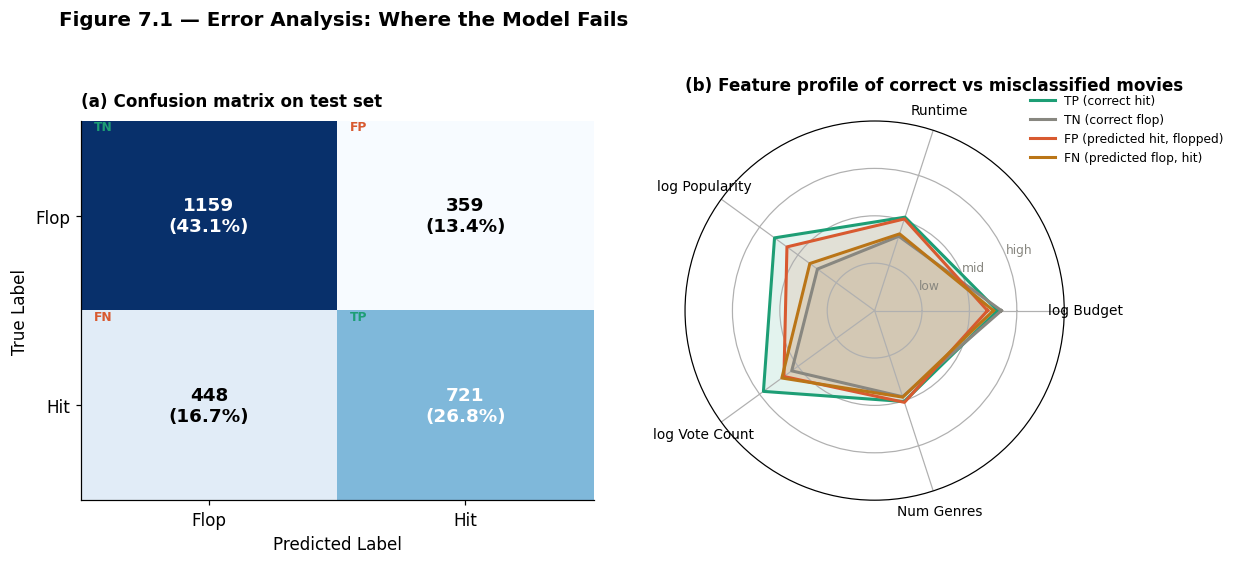

Saved fig_rq7_error_analysis.pdf / .png


In [5]:
# ===== Figure 7.1 — Confusion matrix + error profile radar =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
labels = ["Flop", "Hit"]
im = ax.imshow(cm, cmap="Blues", aspect="auto")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        pct = cm[i, j] / cm.sum() * 100
        ax.text(j, i, f"{cm[i,j]}\n({pct:.1f}%)", ha="center", va="center",
                color=color, fontsize=12, weight="bold")
ax.text(-0.45, -0.45, "TN", fontsize=8, color=COLORS["secondary"], weight="bold")
ax.text(0.55, -0.45, "FP", fontsize=8, color=COLORS["accent"], weight="bold")
ax.text(-0.45, 0.55, "FN", fontsize=8, color=COLORS["accent"], weight="bold")
ax.text(0.55, 0.55, "TP", fontsize=8, color=COLORS["secondary"], weight="bold")
ax.set_title("(a) Confusion matrix on test set", loc="left", pad=10, fontsize=11)

# Radar
ax_radar = fig.add_subplot(1, 2, 2, polar=True)
axes[1].remove()

categories = ["log Budget", "Runtime", "log Popularity", "log Vote Count", "Num Genres"]
def normalize_row(row, ranges):
    out = []
    for c, (lo, hi) in zip(row, ranges):
        v = (c - lo) / (hi - lo) if hi > lo else 0
        out.append(np.clip(v, 0, 1))
    return out

# Compute normalized values per err_class
test_df["log_budget_e"] = np.log1p(test_df["budget"])
test_df["log_pop_e"]    = np.log1p(test_df["popularity"].fillna(0))
test_df["log_vote_e"]   = np.log1p(test_df["vote_count"].fillna(0))
radar_cols = ["log_budget_e", "runtime", "log_pop_e", "log_vote_e", "num_genres"]
ranges = [(test_df[c].quantile(0.05), test_df[c].quantile(0.95)) for c in radar_cols]

err_to_color = {"TP": COLORS["secondary"], "TN": COLORS["gray"],
                "FP": COLORS["accent"], "FN": COLORS["amber"]}
err_to_label = {"TP": "TP (correct hit)", "TN": "TN (correct flop)",
                "FP": "FP (predicted hit, flopped)", "FN": "FN (predicted flop, hit)"}

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for ec in ["TP", "TN", "FP", "FN"]:
    row = test_df.loc[test_df["err_class"]==ec, radar_cols].mean().values
    vals = normalize_row(row, ranges)
    vals_closed = vals + vals[:1]
    ax_radar.plot(angles, vals_closed, linewidth=2, label=err_to_label[ec], color=err_to_color[ec])
    ax_radar.fill(angles, vals_closed, alpha=0.12, color=err_to_color[ec])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75])
ax_radar.set_yticklabels(["low", "mid", "high"], fontsize=8, color=COLORS["gray"])
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.45, 1.10), fontsize=8)
ax_radar.set_title("(b) Feature profile of correct vs misclassified movies", loc="left", pad=20, fontsize=11)

fig.suptitle("Figure 7.1 — Error Analysis: Where the Model Fails", fontsize=13, fontweight="bold", x=0.05, ha="left", y=1.02)
plt.tight_layout()
plt.savefig("fig_rq7_error_analysis.pdf")
plt.savefig("fig_rq7_error_analysis.png")
plt.show()
print("Saved fig_rq7_error_analysis.pdf / .png")


## 6. Conclusion

False positives are typically big-budget films that flopped (e.g. high-profile box-office bombs), while false negatives are 'sleeper hits' — low-budget movies with unexpected success. These patterns reveal the genuine limits of pre-release predictability.